# Layerwise Comparison: HS2SWE vs DeltaSnow

Runs both models layerwise on the full Mag25 dataset (41 stations, 2016–2022)
and merges the results into a single NetCDF with dimensions `(time, station, layer)`.

**Workflow**
1. Load Mag25 HS forcing from `Mag25_all.nc`.
2. Run **HS2SWE** (Python) layerwise → collect `h [m]`, `rho [kg/m³]`, `swe [mm]` per layer.
3. Load **DeltaSnow** layerwise NC produced by `run_dsnow_layerwise.R`.
4. Merge both into `combined_layerwise_Mag25.nc`.

**Prerequisites**  
Run `run_dsnow_layerwise.R` first to generate `dsnow_layerwise_Mag25.nc`.

In [140]:
import sys
import os
import warnings
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path

base_dir = Path("/Users/jakobwerkgarner/code/mt_dsnow")
os.chdir(base_dir)
sys.path.insert(0, str(base_dir / "HS2SWE/model"))

Mag25_nc    = base_dir / "calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc"
dsnow_nc    = base_dir / "model_diff/layerwise_data/dyn_rho_max/dsnow_layerwise_Mag25_default.nc"
out_nc      = base_dir / "model_diff/layerwise_data/dyn_rho_max/combined_layerwise_dyn_rho_max_default_Mag25.nc"

FIGURES_DIR = base_dir / "model_diff/layerwise_comparison/figures_dyn_rho_max"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=FutureWarning)

## HS2SWE Layerwise Function

Extended version of the original `HS2SWE` that additionally returns per-layer
`h [m]` and `rho [kg/m³]` arrays alongside the total SWE output.

In [141]:
def HS2SWE_layerwise(
    idata,
    RhoNew=113.7, RhoMax=571.6, SnoTemp=-0.000, Visc=6.051e7,
    DQMultInc=0.1, DQMultMax=5, HsAcc=2,
    c1=2.8e-6, c2=0.042, c3=0.046, c4=0.081, c5=0.018,
    g=9.81, dt=86400,
):
    """
    HS2SWE with layerwise output.

    Parameters
    ----------
    idata : ndarray (n_time, n_stations)
        Snow depth in **centimetres**.

    Returns
    -------
    odata : ndarray (n_time, n_stations)
        Total SWE [mm].
    all_h : ndarray (n_time, n_stations, max_layers)
        Layer snow depth [m].  NaN outside snow-covered periods.
        Layer 0 = bottom/oldest, layer N = top/newest.
    all_rho : ndarray (n_time, n_stations, max_layers)
        Layer density [kg/m³].  NaN outside snow-covered periods.
    all_n_layers : ndarray (n_time, n_stations), int16
        Number of active layers (h > 0) at each timestep.
    all_MR : list of lists of dict
        all_MR[station][segment] — full MR dict (HS, RHO, OVB, AGE, DIA)
        for each continuous snow-covered segment, for inspection.
    station_segments : list of lists of dict
        station_segments[station][segment] — {"idx": global_time_indices, "h_cm", "rho"}
        Parallel structure to all_MR; idx maps MR columns (1-based) to global time indices.
    """
    assert np.all(idata[~np.isnan(idata)] >= 0), "Negative values in input data"

    PAR = {"c1": c1, "c2": c2, "c3": c3, "c4": c4, "c5": c5, "g": g, "dt": dt}
    n_time, n_stations = idata.shape
    odata = np.zeros_like(idata)

    # Collect (global_idx, h_cm, rho) per station segment
    station_segments = [[] for _ in range(n_stations)]
    all_MR           = [[] for _ in range(n_stations)]
    max_layers = 1

    for serix in range(n_stations):
        print(f"  HS2SWE station {serix + 1}/{n_stations}", end="\r")

        psdix = np.where((~np.isnan(idata[:, serix])) & (idata[:, serix] > 0))[0]
        if psdix.size == 0:
            continue

        sepix = np.concatenate(([0], np.where(np.diff(psdix) > 1)[0] + 1, [len(psdix)]))

        for tsrix in range(len(sepix) - 1):
            global_idx = np.arange(psdix[sepix[tsrix]], psdix[sepix[tsrix + 1] - 1] + 1)
            HS = np.concatenate(([0], idata[global_idx, serix]))

            MR = {
                "HS":  np.zeros((1, len(HS))),
                "RHO": np.ones((1, len(HS))) * RhoMax,
                "OVB": np.zeros((1, len(HS))),
                "AGE": np.arange(len(HS), dtype=float).reshape(1, -1),
                "DIA": np.zeros((5, len(HS))),
            }

            for tn in range(1, len(HS)):
                # Step 1: Densification of existing layer (limited by RhoMax); ATTN: any changes of the below line need to be replicated in step 3.3
                MR["RHO"][:, tn] = np.minimum(
                    MR["RHO"][:, tn - 1]
                    + MR["RHO"][:, tn - 1]
                    * PAR["dt"]
                    * (
                        MR["OVB"][:, tn - 1]
                        * PAR["g"]
                        / (Visc * np.exp(PAR["c4"] * SnoTemp + PAR["c5"] * MR["RHO"][:, tn - 1]))
                        + PAR["c1"]
                        * np.exp(
                            -PAR["c2"] * SnoTemp
                            - PAR["c3"] * np.maximum(0, MR["RHO"][:, tn - 1] - RhoNew)
                        )
                    ),
                    RhoMax,
                )
                # Step 2: settling of snow according to step 1 assuming constant SWE; %ATTN: any changes of the below line need to be replicated in step 3.3
                MR["HS"][:, tn] = MR["HS"][:, tn - 1] / (MR["RHO"][:, tn] / MR["RHO"][:, tn - 1])

                # Step 3: Assimilate measured HS (add new snow / melt snow)
                # Step 3.0 if HSmeas > HSmod for first time step assume new snow fall and add layer
                if HS[tn] > np.sum(MR["HS"][:, tn]) and tn == 1:
                    nlix = MR["HS"].shape[0] + 1
                    MR["HS"]  = np.vstack([MR["HS"],  np.zeros((1, len(HS)))])
                    MR["HS"][nlix - 1, tn]  = HS[tn] - np.sum(MR["HS"][:, tn])
                    MR["RHO"] = np.vstack([MR["RHO"], np.ones((1, len(HS))) * RhoNew])
                    MR["OVB"] = np.vstack([MR["OVB"], np.zeros((1, len(HS)))])
                    MR["AGE"] = np.vstack([MR["AGE"], np.zeros((1, len(HS)))])
                    MR["AGE"][nlix - 1, tn:] = np.arange(len(HS) - tn)

                    if HS[tn] < HS[tn - 1]:
                        MR["DIA"][0, tn] = 1  # if observed HS is decreasing while model adds new snow add a note in MR.DIA

               # Step 3.1: If HSmeas > HSmod + HSacc, assume new snow fall and add layer
                elif HS[tn] > np.sum(MR["HS"][:, tn]) + HsAcc:
                    nlix = MR["HS"].shape[0] + 1
                    MR["HS"]  = np.vstack([MR["HS"],  np.zeros((1, len(HS)))])
                    MR["HS"][nlix - 1, tn]  = HS[tn] - np.sum(MR["HS"][:, tn])
                    MR["RHO"] = np.vstack([MR["RHO"], np.ones((1, len(HS))) * RhoNew])
                    MR["OVB"] = np.vstack([MR["OVB"], np.zeros((1, len(HS)))])
                    MR["AGE"] = np.vstack([MR["AGE"], np.zeros((1, len(HS)))])
                    MR["AGE"][nlix - 1, tn:] = np.arange(len(HS) - tn)

                    if HS[tn] < HS[tn - 1]:
                        MR["DIA"][0, tn] = 1  # if observed HS is decreasing while model adds new snow add a note in MR.DIA

                # Step 3.2: If HSmeas == HSmod, don't do anything
                elif HS[tn] == np.sum(MR["HS"][:, tn]):
                    MR["DIA"][1, tn] = 0  # note difference between HSmeas - HSmod if positive in MR.DIA

                # Step 3.3: If HSmeas > HSmod, reapply densification with gradually decreasing densification rate until HSmeas <= HSmod
                elif HS[tn] > np.sum(MR["HS"][:, tn]):
                    MR["DIA"][1, tn] = HS[tn] - np.sum(MR["HS"][:, tn])  # note difference between HSmeas - HSmod before assimilation

                    # step 3.3.1 decreasing deinsification rate
                    DQMultCur = 1
                    while (
                        np.mean(MR["RHO"][:, tn]) < RhoMax
                        and HS[tn] > np.sum(MR["HS"][:, tn])
                        and DQMultCur < DQMultMax
                    ):
                        DQMultCur += DQMultInc
                        MR["RHO"][:, tn] = np.minimum(
                            MR["RHO"][:, tn - 1]
                            + MR["RHO"][:, tn - 1]
                            * PAR["dt"]
                            * (
                                MR["OVB"][:, tn - 1]
                                * PAR["g"]
                                / (Visc * np.exp(PAR["c4"] * SnoTemp + PAR["c5"] * MR["RHO"][:, tn - 1]))
                                + PAR["c1"]
                                * np.exp(
                                    -PAR["c2"] * SnoTemp
                                    - PAR["c3"] * np.maximum(0, MR["RHO"][:, tn - 1] - RhoNew)
                                )
                            )
                            / DQMultCur,
                            RhoMax,
                        )
                        MR["HS"][:, tn] = MR["HS"][:, tn - 1] / (MR["RHO"][:, tn] / MR["RHO"][:, tn - 1])

                    MR["DIA"][2, tn] = HS[tn] - np.sum(MR["HS"][:, tn])  # note difference between HSmeas - HSmod after assimilation
                    MR["DIA"][3, tn] = -DQMultCur                         # note assimilation steps required to match HSmeas (negative for decreasing densification)

                    # step 3.3.2 if still HSmeas > HSmod (because of RhoMax or because of MAXITER) don't do anything
                    if HS[tn] > np.sum(MR["HS"][:, tn]):
                        # don't do anything
                        # later eventually add snow layer MR['DIA'][5, tn]
                        MR["DIA"][4, tn] = -1  # note when densification was too high to meet HS

                # step 3.4 if HSmeas < HSmod reapply densification with gradually increasing densification rate until HSmeas >= HSmod or MR.RHO == RHOmax for all layers
                elif HS[tn] < np.sum(MR["HS"][:, tn]):
                        MR["DIA"][1, tn] = HS[tn] - np.sum(MR["HS"][:, tn])  # note difference between HSmeas - HSmod before assimilation

                        # step 3.4.1 increase densification rate
                        DQMultCur = 1
                        while (
                            np.mean(MR["RHO"][:, tn]) < RhoMax
                            and HS[tn] < np.sum(MR["HS"][:, tn])
                            and DQMultCur < DQMultMax
                        ):
                            DQMultCur += DQMultInc
                            MR["RHO"][:, tn] = np.minimum(
                                (
                                    MR["RHO"][:, tn - 1]
                                    + MR["RHO"][:, tn - 1]
                                    * PAR["dt"]
                                    * (
                                        MR["OVB"][:, tn - 1]
                                        * PAR["g"]
                                        / (Visc * np.exp(PAR["c4"] * SnoTemp + PAR["c5"] * MR["RHO"][:, tn - 1]))
                                        + PAR["c1"]
                                        * np.exp(
                                            -PAR["c2"] * SnoTemp
                                            - PAR["c3"] * np.maximum(0, MR["RHO"][:, tn - 1] - RhoNew)
                                        )
                                    )
                                    * DQMultCur
                                ),
                                RhoMax,
                            )
                            MR["HS"][:, tn] = MR["HS"][:, tn - 1] / (MR["RHO"][:, tn] / MR["RHO"][:, tn - 1])

                        MR["DIA"][2, tn] = HS[tn] - np.sum(MR["HS"][:, tn])  # note difference between HSmeas - HSmod after assimilation
                        MR["DIA"][3, tn] = DQMultCur  # note assimilation steps required to match HSmeas (positive for increasing densification)

                        #step 3.4.2 if still HSmeas < HSmod (because of RhoMax or MAXITER) start melting from above
                        if HS[tn] < np.sum(MR["HS"][:, tn]):
                            for lix in range(len(MR["HS"]) - 1, -1, -1):

                                MR["HS"][lix, tn] = HS[tn] - np.sum(MR["HS"][:lix, tn])

                                if MR["HS"][lix, tn] >= 0:
                                    break
                                else:
                                    MR["HS"][lix, tn] = 0
                            MR["DIA"][4, tn] = 1  # note when melt condition met 
                else:
                    # this case should not happen
                    raise Exception("Unexpected case")

                # Step 4: Recalculate overburden
                nlix = MR["HS"].shape[0]
                MR["OVB"][nlix - 1, tn] = 0
                for nlix in range(MR["HS"].shape[0] - 2, -1, -1):
                    MR["OVB"][nlix, tn] = np.sum(MR["HS"][nlix + 1:, tn] * MR["RHO"][nlix + 1:, tn] / 100)

            SWE = np.sum(MR["HS"] * MR["RHO"] / 100, axis=0)
            odata[global_idx, serix] = SWE[1:]

            nlayers = MR["HS"].shape[0]
            if nlayers > max_layers:
                max_layers = nlayers
            station_segments[serix].append(
                {
                    "idx": global_idx,
                    "h_cm": MR["HS"][:, 1:],   # (nlayers, seg_len)
                    "rho":  MR["RHO"][:, 1:],   # (nlayers, seg_len)
                }
            )
            all_MR[serix].append(MR)

    odata[idata == 0] = 0
    print(f"  HS2SWE done. Max layers: {max_layers}")

    # Allocate layerwise output arrays: (n_time, n_stations, max_layers)
    all_h        = np.full((n_time, n_stations, max_layers), np.nan, dtype=np.float32)
    all_rho      = np.full((n_time, n_stations, max_layers), np.nan, dtype=np.float32)
    all_n_layers = np.zeros((n_time, n_stations), dtype=np.int16)

    for si, segments in enumerate(station_segments):
        for seg in segments:
            idx  = seg["idx"]
            h_cm = seg["h_cm"]   # (nlayers, seg_len)
            rho  = seg["rho"]    # (nlayers, seg_len)
            nl   = h_cm.shape[0]
            for li in range(nl):
                all_h  [idx, si, li] = h_cm[li] / 100.0   # cm → m
                all_rho[idx, si, li] = rho[li]
            # count active layers (h > 0) at each timestep in this segment
            all_n_layers[idx, si] = np.sum(h_cm > 0, axis=0).astype(np.int16)

    return odata, all_h, all_rho, all_n_layers, all_MR, station_segments

## Load Mag25 Forcing Data

In [142]:
ds_mag25 = xr.open_dataset(Mag25_nc)
station_names = ds_mag25["station"].values
times         = ds_mag25["time"].values
HS_m          = ds_mag25["HS"].values          # (time, station), metres
HS_cm         = HS_m * 100                     # → cm for HS2SWE

n_time, n_stations = HS_m.shape
print(f"Mag25: {n_stations} stations × {n_time} time steps")
print(f"Period: {pd.Timestamp(times[0]).date()} – {pd.Timestamp(times[-1]).date()}")
print(f"Stations: {list(station_names)}")

# Exclude stations that should not be evaluated
EXCLUDE_STATIONS = {"Weisfluh_Joch"}
exclude_mask = np.array([str(s) in EXCLUDE_STATIONS for s in station_names])
HS_cm[:, exclude_mask] = np.nan   # NaN → skipped by HS2SWE (psdix empty)
HS_m[:, exclude_mask]  = np.nan   # keep consistent for obs variable in output NC
print(f"\nExcluded from evaluation: {list(station_names[exclude_mask])}")

Mag25: 41 stations × 2191 time steps
Period: 2016-09-01 – 2022-08-31
Stations: [np.str_('Adelboden'), np.str_('Gadmen'), np.str_('Grindelwald_Bort'), np.str_('Gsteig'), np.str_('Gantrisch'), np.str_('Leysin'), np.str_('Muerren'), np.str_('Saanenmoeser'), np.str_('Wengen'), np.str_('Srenberg'), np.str_('Stoos'), np.str_('Braunwald'), np.str_('Malbun'), np.str_('St_Margrethenberg'), np.str_('Binn'), np.str_('Bourg_St_Pierre'), np.str_('Fionnay'), np.str_('Grimentz'), np.str_('Lauchernalp'), np.str_('Montana'), np.str_('Muenster'), np.str_('Saas_Fee'), np.str_('Simplon_Dorf'), np.str_('Ulrichen'), np.str_('Wiler'), np.str_('Bivio'), np.str_('Davos_Flueelastr'), np.str_('Juf'), np.str_('Obersaxen'), np.str_('Pusserein'), np.str_('St_Antoenien'), np.str_('Sedrun'), np.str_('Spluegen'), np.str_('Vals'), np.str_('Weisfluh_Joch'), np.str_('Bosco_Gurin'), np.str_('San_Bernadino'), np.str_('Maloja'), np.str_('Sankt_Moritz'), np.str_('Samnaun'), np.str_('Zuoz')]

Excluded from evaluation: [np.str

## Run HS2SWE Layerwise

Processes all stations at once with default parameters.
Runtime: ~2–5 min for 41 stations × 2191 days.

In [143]:
import time as _time

print("Running HS2SWE layerwise on all stations…")
t0 = _time.time()

hs2swe_swe_total, hs2swe_h, hs2swe_rho, hs2swe_n_layers, all_MR, station_segments = HS2SWE_layerwise(HS_cm)

# Derive per-layer SWE [mm] = h [m] * rho [kg/m³]  (1 m × 1 kg/m³ = 1 mm w.e.)
hs2swe_swe = hs2swe_h * hs2swe_rho   # mm

print(f"HS2SWE done in {_time.time() - t0:.1f} s")
print(f"  SWE total shape  : {hs2swe_swe_total.shape}")
print(f"  Layerwise h shape: {hs2swe_h.shape}   (time × station × layer)")
print(f"  Max layers       : {hs2swe_h.shape[2]}")
print(f"  n_layers shape   : {hs2swe_n_layers.shape}")
print(f"  all_MR           : {sum(len(s) for s in all_MR)} segments across {len(all_MR)} stations")

Running HS2SWE layerwise on all stations…
  HS2SWE done. Max layers: 78
HS2SWE done in 17.8 s
  SWE total shape  : (2191, 41)
  Layerwise h shape: (2191, 41, 78)   (time × station × layer)
  Max layers       : 78
  n_layers shape   : (2191, 41)
  all_MR           : 1564 segments across 41 stations


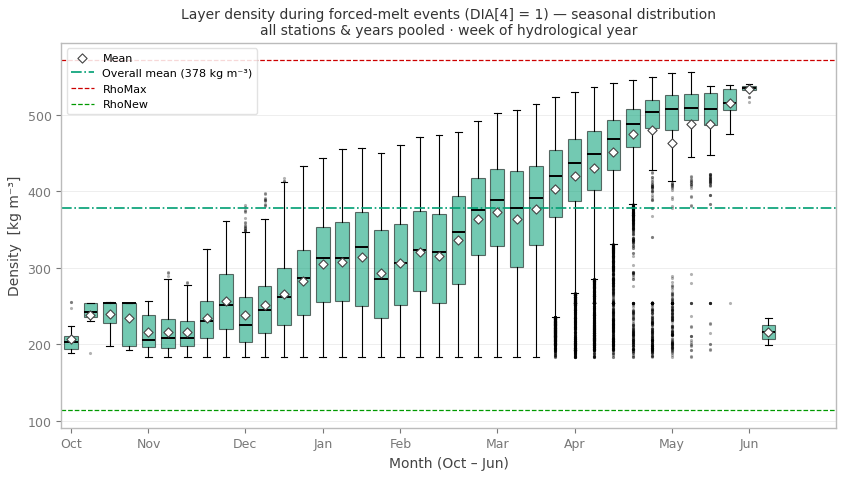

In [144]:
import sys
sys.path.insert(0, str(base_dir))
from plot_style import apply_style, C, FIG, ALPHA
import matplotlib.pyplot as plt

apply_style()

def hydro_week(global_tn):
    ts = pd.Timestamp(times[global_tn])
    sep1 = pd.Timestamp(ts.year if ts.month >= 9 else ts.year - 1, 9, 1)
    doy = (ts - sep1).days + 1
    return max(1, min(52, (doy - 1) // 7 + 1))

# Oct → Jun only (hydro-weeks 5–44)
WEEK_MIN, WEEK_MAX = 5, 44
WEEK_LABELS = {5: "Oct", 9: "Nov", 14: "Dec", 18: "Jan",
               22: "Feb", 27: "Mar", 31: "Apr", 36: "May", 40: "Jun"}

melt_by_week = {w: [] for w in range(1, 53)}

for si in range(len(all_MR)):
    for seg_i, MR in enumerate(all_MR[si]):
        global_idx = station_segments[si][seg_i]["idx"]
        melt_tn = np.where(MR["DIA"][4, :] == 1)[0]
        for tn in melt_tn:
            if tn == 0 or tn > len(global_idx):
                continue
            gidx = global_idx[tn - 1]
            week = hydro_week(gidx)
            for lix in range(MR["HS"].shape[0]):
                if MR["HS"][lix, tn] > 0:
                    melt_by_week[week].append(MR["RHO"][lix, tn])

weeks_used  = [w for w in range(WEEK_MIN, WEEK_MAX + 1) if melt_by_week[w]]
data_used   = [melt_by_week[w] for w in weeks_used]
means_used  = [np.mean(d) for d in data_used]
overall     = np.mean([v for d in data_used for v in d])

fig, ax = plt.subplots(figsize=FIG.SINGLE)

ax.boxplot(
    data_used,
    positions=weeks_used,
    widths=0.7,
    patch_artist=True,
    boxprops=dict(facecolor=C.HS2SWE, alpha=0.55, linewidth=0.8),
    medianprops=dict(color="black", linewidth=1.4),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    flierprops=dict(marker=".", markersize=2.5, alpha=0.3, color=C.HS2SWE),
)
ax.scatter(weeks_used, means_used, marker="D", s=22, color="white",
           edgecolors="#444444", linewidths=0.8, zorder=5, label="Mean")

ax.axhline(overall, color=C.HS2SWE, lw=1.2, ls="-.",
           label=f"Overall mean ({overall:.0f} kg m⁻³)")
ax.axhline(571.6, color="#CC0000", lw=0.9, ls="--", label="RhoMax")
ax.axhline(113.7, color="#009900", lw=0.9, ls="--", label="RhoNew")

ax.set_xticks(list(WEEK_LABELS))
ax.set_xticklabels([WEEK_LABELS[w] for w in WEEK_LABELS])
ax.set_xlim(WEEK_MIN - 0.5, WEEK_MAX + 0.5)
ax.set_xlabel("Month (Oct – Jun)")
ax.set_ylabel("Density  [kg m⁻³]")
ax.set_title(
    "Layer density during forced-melt events (DIA[4] = 1) — seasonal distribution\n"
    "all stations & years pooled · week of hydrological year",
    fontsize=10,
)
ax.legend(fontsize=8)

fig.savefig(FIGURES_DIR / "melt_density_seasonal.png", **FIG.SAVE)
plt.show()

## Load DeltaSnow Layerwise NC

Generated by `run_dsnow_layerwise.R`.

In [145]:
if not dsnow_nc.exists():
    raise FileNotFoundError(
        f"{dsnow_nc}\nRun `run_dsnow_layerwise.R` first to generate this file."
    )

# decode_times=False prevents xarray from misinterpreting dsnow_age (units="days")
# as timedelta64.  We re-decode the proper time axis manually below.
ds_dsnow = xr.open_dataset(dsnow_nc, decode_times=False)
time_units = ds_dsnow["time"].attrs.get("units", "")
time_cal   = ds_dsnow["time"].attrs.get("calendar", "standard")
ds_dsnow["time"] = xr.coding.times.decode_cf_datetime(
    ds_dsnow["time"].values, units=time_units, calendar=time_cal,
)
print(ds_dsnow)

# R/ncdf4 writes Fortran order: list(dim_layer, dim_time, dim_station) →
# xarray reads C order → dims appear as (station, time, layer).
# Use xarray's named transpose — works regardless of stored order.
dsnow_h         = ds_dsnow["dsnow_h"].transpose("time", "station", "layer").values
dsnow_swe_layer = ds_dsnow["dsnow_swe"].transpose("time", "station", "layer").values
dsnow_rho       = ds_dsnow["dsnow_rho"].transpose("time", "station", "layer").values
# 2D: list(dim_station, dim_time) → xarray reads as (time, station) — no transpose needed
dsnow_swe_total = ds_dsnow["dsnow_swe_total"].values   # (time, station)

# Diagnostics (2D: station × time in NC → transpose to time × station)
dsnow_process  = ds_dsnow["dsnow_process"].transpose("time", "station").values   # int
dsnow_n_layers = ds_dsnow["dsnow_n_layers"].transpose("time", "station").values  # int

n_dsnow_layers = dsnow_h.shape[2]
print(f"\nDeltaSnow layerwise: {dsnow_h.shape}  expected ({n_time}, {n_stations}, ?)")
print(f"Max dsnow layers   : {n_dsnow_layers}")
print(f"dsnow_process shape: {dsnow_process.shape}")
assert dsnow_h.shape[:2] == (n_time, n_stations), f"Shape mismatch: {dsnow_h.shape}"
print("Shape OK.")

<xarray.Dataset> Size: 106MB
Dimensions:          (station: 41, time: 2191, layer: 72)
Coordinates:
  * station          (station) |S17 697B b'Adelboden' b'Gadmen' ... b'Zuoz'
  * time             (time) datetime64[ns] 18kB 2016-09-01T06:00:00 ... 2022-...
  * layer            (layer) int32 288B 1 2 3 4 5 6 7 8 ... 66 67 68 69 70 71 72
Data variables:
    dsnow_swe_total  (time, station) float64 719kB ...
    dsnow_h          (station, time, layer) float32 26MB ...
    dsnow_swe        (station, time, layer) float32 26MB ...
    dsnow_rho        (station, time, layer) float32 26MB ...
    dsnow_age        (station, time, layer) float32 26MB ...
    dsnow_process    (time, station) float64 719kB ...
    dsnow_n_layers   (time, station) float64 719kB ...
Attributes:
    source:         nixmass::swe.delta.snow, layers=TRUE
    forcing:        /Users/jakobwerkgarner/code/mt_dsnow/calibration/calibrat...
    dyn_rho_max:    1
    n_stations:     41
    n_timesteps:    2191
    max_layers:  

## Merge and Write Combined NetCDF

Both models are padded to a shared `layer` dimension
`max(hs2swe_max_layers, dsnow_max_layers)`.

Layer convention: **0 = bottom/oldest, N = top/newest** (same for both models).

In [146]:
n_hs2swe_layers = hs2swe_h.shape[2]
max_layers      = max(n_hs2swe_layers, n_dsnow_layers)

def pad_layers(arr, target_layers):
    """Pad (time, station, layer) array with NaN to target_layers on the layer axis."""
    current = arr.shape[2]
    if current == target_layers:
        return arr
    pad_width = target_layers - current
    pad = np.full(arr.shape[:2] + (pad_width,), np.nan, dtype=arr.dtype)
    return np.concatenate([arr, pad], axis=2)

# Pad both models to shared layer dimension
hs2swe_h_p   = pad_layers(hs2swe_h,         max_layers)
hs2swe_rho_p = pad_layers(hs2swe_rho,        max_layers)
hs2swe_swe_p = pad_layers(hs2swe_swe,        max_layers)
dsnow_h_p    = pad_layers(dsnow_h.astype(np.float32),   max_layers)
dsnow_rho_p  = pad_layers(dsnow_rho.astype(np.float32), max_layers)
dsnow_swe_p  = pad_layers(dsnow_swe_layer.astype(np.float32), max_layers)

print(f"Shared layer dimension: {max_layers}")
print(f"  HS2SWE layers: {n_hs2swe_layers}")
print(f"  DeltaSnow layers: {n_dsnow_layers}")

Shared layer dimension: 78
  HS2SWE layers: 78
  DeltaSnow layers: 72


In [147]:
layer_coords = np.arange(max_layers)

ds_out = xr.Dataset(
    {
        # ── Observations ──────────────────────────────────────────────────────
        "HS_obs": (
            ["time", "station"],
            HS_m.astype(np.float32),
            {"units": "m", "long_name": "Observed snow depth"},
        ),
        # ── HS2SWE totals ─────────────────────────────────────────────────────
        "hs2swe_swe_total": (
            ["time", "station"],
            hs2swe_swe_total.astype(np.float32),
            {"units": "mm", "long_name": "HS2SWE total SWE"},
        ),
        # ── HS2SWE layerwise ──────────────────────────────────────────────────
        "hs2swe_h": (
            ["time", "station", "layer"],
            hs2swe_h_p,
            {"units": "m", "long_name": "HS2SWE layer snow depth"},
        ),
        "hs2swe_rho": (
            ["time", "station", "layer"],
            hs2swe_rho_p,
            {"units": "kg m-3", "long_name": "HS2SWE layer density"},
        ),
        "hs2swe_swe": (
            ["time", "station", "layer"],
            hs2swe_swe_p,
            {"units": "mm", "long_name": "HS2SWE layer SWE"},
        ),
        # ── HS2SWE diagnostics ────────────────────────────────────────────────
        "hs2swe_n_layers": (
            ["time", "station"],
            hs2swe_n_layers,
            {"units": "1", "long_name": "HS2SWE number of active snow layers (h > 0)"},
        ),
        # ── DeltaSnow totals ──────────────────────────────────────────────────
        "dsnow_swe_total": (
            ["time", "station"],
            dsnow_swe_total.astype(np.float32),
            {"units": "mm", "long_name": "DeltaSnow total SWE"},
        ),
        # ── DeltaSnow layerwise ───────────────────────────────────────────────
        "dsnow_h": (
            ["time", "station", "layer"],
            dsnow_h_p,
            {"units": "m", "long_name": "DeltaSnow layer snow depth"},
        ),
        "dsnow_rho": (
            ["time", "station", "layer"],
            dsnow_rho_p,
            {"units": "kg m-3", "long_name": "DeltaSnow layer density"},
        ),
        "dsnow_swe": (
            ["time", "station", "layer"],
            dsnow_swe_p,
            {"units": "mm", "long_name": "DeltaSnow layer SWE"},
        ),
        # ── DeltaSnow diagnostics ─────────────────────────────────────────────
        "dsnow_n_layers": (
            ["time", "station"],
            dsnow_n_layers,
            {"units": "1", "long_name": "DeltaSnow number of active snow layers (h > 0)"},
        ),
        "dsnow_process": (
            ["time", "station"],
            dsnow_process,
            {
                "units": "1",
                "long_name": "DeltaSnow process code per timestep",
                "flag_values": np.array([-1, 0, 1, 2, 3, 99], dtype=np.int32),
                "flag_meanings": "runoff no_snow first_layer new_layer drenching unknown",
                "note": (
                    "-1=runoff (season end, HS→0); "
                    "0=no snow; "
                    "1=first layer produced (season start); "
                    "2=new layer created (fresh snow > tau threshold); "
                    "3=drenching/melt (HS decrease > tau threshold)"
                ),
            },
        ),
    },
    coords={
        "time":    times,
        "station": station_names,
        "layer":   layer_coords,
    },
    attrs={
        "title":            "Layerwise comparison: HS2SWE vs DeltaSnow",
        "forcing":          str(Mag25_nc),
        "layer_convention": "0=bottom/oldest, N=top/newest",
        "hs2swe_source":    "HS2SWE/model/HS2SWE.py (Python)",
        "dsnow_source":     "nixmass::swe.delta.snow, layers=TRUE (R)",
        "creation_date":    str(pd.Timestamp.now()),
    },
)

# Add metadata to layer coordinate
ds_out["layer"].attrs = {
    "long_name": "Snow layer index",
    "units":     "1",
    "note":      "0 = bottom/oldest layer, N = top/newest layer",
}

encoding = {
    v: {"zlib": True, "complevel": 4, "_FillValue": np.float32(np.nan)}
    for v in ds_out.data_vars
    if ds_out[v].dtype.kind == "f"
}

out_nc.parent.mkdir(parents=True, exist_ok=True)
ds_out.to_netcdf(out_nc, encoding=encoding)
print(f"Wrote: {out_nc}")
print(ds_out)

/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_5532/128164521.py:42: RuntimeWarning: invalid value encountered in cast
  dsnow_swe_total.astype(np.float32),


Wrote: /Users/jakobwerkgarner/code/mt_dsnow/model_diff/layerwise_data/dyn_rho_max/combined_layerwise_dyn_rho_max_default_Mag25.nc
<xarray.Dataset> Size: 171MB
Dimensions:           (time: 2191, station: 41, layer: 78)
Coordinates:
  * time              (time) datetime64[ns] 18kB 2016-09-01T06:00:00 ... 2022...
  * station           (station) <U17 3kB 'Adelboden' 'Gadmen' ... 'Zuoz'
  * layer             (layer) int64 624B 0 1 2 3 4 5 6 ... 71 72 73 74 75 76 77
Data variables:
    HS_obs            (time, station) float32 359kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    hs2swe_swe_total  (time, station) float32 359kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    hs2swe_h          (time, station, layer) float32 28MB nan nan ... nan nan
    hs2swe_rho        (time, station, layer) float32 28MB nan nan ... nan nan
    hs2swe_swe        (time, station, layer) float32 28MB nan nan ... nan nan
    hs2swe_n_layers   (time, station) int16 180kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    dsnow_swe_total   (time, station) float32

## Quick Sanity Check

Verify that total SWE from the layerwise arrays matches the directly computed totals.

In [148]:
ds_check = xr.open_dataset(out_nc)

# HS2SWE: sum of layer SWE should match total SWE (where defined)
hs2swe_layer_sum = ds_check["hs2swe_swe"].sum(dim="layer", skipna=True, min_count=1)
diff_hs2swe = (hs2swe_layer_sum - ds_check["hs2swe_swe_total"]).values
valid = ~np.isnan(diff_hs2swe)
print(f"HS2SWE  layer-sum vs total: max |diff| = {np.abs(diff_hs2swe[valid]).max():.4f} mm")

# DeltaSnow: same check
dsnow_layer_sum = ds_check["dsnow_swe"].sum(dim="layer", skipna=True, min_count=1)
diff_dsnow = (dsnow_layer_sum - ds_check["dsnow_swe_total"]).values
valid = ~np.isnan(diff_dsnow)
print(f"DeltaSnow layer-sum vs total: max |diff| = {np.abs(diff_dsnow[valid]).max():.4f} mm")

# Show station-mean total SWE for a few stations
swe_summary = pd.DataFrame({
    "station":          ds_check["station"].values,
    "hs2swe_mean_swe":  ds_check["hs2swe_swe_total"].mean("time", skipna=True).values,
    "dsnow_mean_swe":   ds_check["dsnow_swe_total"].mean("time", skipna=True).values,
    "hs2swe_max_layers": (
        (~np.isnan(ds_check["hs2swe_h"].values))
        .any(axis=(0, 1))   # which layers are ever non-NaN
        .sum()
    ),
    "dsnow_max_layers": (
        (~np.isnan(ds_check["dsnow_h"].values))
        .any(axis=(0, 1))
        .sum()
    ),
})

print(f"\nMax layers actually used:")
print(f"  HS2SWE   : {int(swe_summary['hs2swe_max_layers'].iloc[0])}")
print(f"  DeltaSnow: {int(swe_summary['dsnow_max_layers'].iloc[0])}")
print()
print(swe_summary[["station", "hs2swe_mean_swe", "dsnow_mean_swe"]].to_string(index=False))

ds_check.close()

HS2SWE  layer-sum vs total: max |diff| = 0.0001 mm
DeltaSnow layer-sum vs total: max |diff| = 0.0001 mm

Max layers actually used:
  HS2SWE   : 78
  DeltaSnow: 72

          station  hs2swe_mean_swe  dsnow_mean_swe
        Adelboden        14.969872       15.078783
           Gadmen        70.869629       71.913628
 Grindelwald_Bort        71.876518       76.281693
           Gsteig        47.844814       45.566391
        Gantrisch        76.731750       80.182793
           Leysin        26.418768       27.291128
          Muerren        86.214363       88.090004
     Saanenmoeser        37.226665       38.576374
           Wengen        21.936216       23.817652
         Srenberg        10.666477       10.465466
            Stoos        76.749084       78.703033
        Braunwald        76.063835       78.320190
           Malbun        76.792229       80.675888
St_Margrethenberg        27.951866       28.539707
             Binn        42.812336       43.113098
  Bourg_St_Pierre   

## Diagnostics: Process Codes & Layer Counts

### DeltaSnow process codes
`dsnow_process` encodes what the model did at each timestep (from `out$processes` in nixmass):

| Code | Meaning |
|-----:|---------|
| `-1` | **Runoff** — all snow melted, HS dropped to 0 (end of season) |
| `0`  | **No snow** — HS = 0, pack absent |
| `1`  | **First layer produced** — start of snow season |
| `2`  | **New layer created** — fresh snowfall exceeded the `tau` threshold |
| `3`  | **Drenching / melt** — HS decreased by more than `tau` (compaction + potential runoff) |
| `99` | Unrecognised label |

### `n_layers` for both models
- `dsnow_n_layers` / `hs2swe_n_layers`: count of layers with h > 0 at each timestep.  
  Larger stacks = many distinct snowfall events still tracked separately.
  DeltaSnow tends to be more parsimonious (fewer layers) because it uses a threshold `tau`.

In [149]:
ds_diag = xr.open_dataset(out_nc)

PROCESS_LABELS = {
    -1: "runoff",
    0:  "no snow",
    1:  "first layer",
    2:  "new layer",
    3:  "drenching",
    99: "unknown",
}

# ── 1. Process frequency table (DeltaSnow, all stations pooled) ───────────────
proc_flat = ds_diag["dsnow_process"].values.ravel()
proc_counts = pd.Series(proc_flat).value_counts().sort_index()
proc_df = pd.DataFrame({
    "code":  proc_counts.index,
    "count": proc_counts.values,
    "label": [PROCESS_LABELS.get(c, "?") for c in proc_counts.index],
    "pct":   (proc_counts.values / proc_counts.values.sum() * 100).round(2),
})
print("=== DeltaSnow process distribution (all stations × all timesteps) ===")
print(proc_df.to_string(index=False))
print()

# ── 2. Per-station new-snow-layer event count ─────────────────────────────────
proc_arr = ds_diag["dsnow_process"].values   # (time, station)
new_layer_counts = (proc_arr == 2).sum(axis=0)   # per station
drenching_counts = (proc_arr == 3).sum(axis=0)
event_df = pd.DataFrame({
    "station":          ds_diag["station"].values,
    "new_layer_events": new_layer_counts,
    "drenching_events": drenching_counts,
    "dsnow_max_layers": ds_diag["dsnow_n_layers"].max("time").values,
    "hs2swe_max_layers":ds_diag["hs2swe_n_layers"].max("time").values,
}).sort_values("dsnow_max_layers", ascending=False)
print("=== Per-station diagnostics ===")
print(event_df.to_string(index=False))
print()

# ── 3. Season-mean n_layers: DeltaSnow vs HS2SWE ─────────────────────────────
# Only average over snow-covered days (n_layers > 0)
d_nl = ds_diag["dsnow_n_layers"].values.astype(float)
h_nl = ds_diag["hs2swe_n_layers"].values.astype(float)
d_nl[d_nl == 0] = np.nan
h_nl[h_nl == 0] = np.nan

layer_cmp = pd.DataFrame({
    "station":              ds_diag["station"].values,
    "dsnow_mean_n_layers":  np.nanmean(d_nl, axis=0).round(1),
    "hs2swe_mean_n_layers": np.nanmean(h_nl, axis=0).round(1),
})
layer_cmp["ratio_hs2swe/dsnow"] = (
    layer_cmp["hs2swe_mean_n_layers"] / layer_cmp["dsnow_mean_n_layers"]
).round(2)
print("=== Mean active layers during snow-covered days (HS2SWE typically stacks more) ===")
print(layer_cmp.sort_values("ratio_hs2swe/dsnow", ascending=False).to_string(index=False))

ds_diag.close()

=== DeltaSnow process distribution (all stations × all timesteps) ===
 code  count       label   pct
 -1.0   1564      runoff  1.74
  0.0  53840     no snow 59.93
  1.0   1564 first layer  1.74
  2.0  25146   new layer 27.99
  3.0   7717   drenching  8.59

=== Per-station diagnostics ===
          station  new_layer_events  drenching_events  dsnow_max_layers  hs2swe_max_layers
      Lauchernalp               782               249              72.0                 71
        Gantrisch               758               212              61.0                 46
          Fionnay               757               190              59.0                 59
         Saas_Fee               757               129              58.0                 58
     St_Antoenien               660               265              56.0                 50
           Maloja               839               187              55.0                 47
              Juf               902               223              55.0   

/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_5532/2234373698.py:49: RuntimeWarning: Mean of empty slice
  "dsnow_mean_n_layers":  np.nanmean(d_nl, axis=0).round(1),
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_5532/2234373698.py:50: RuntimeWarning: Mean of empty slice
  "hs2swe_mean_n_layers": np.nanmean(h_nl, axis=0).round(1),


## Mean Seasonal Cycle: Active Snow Layers

Mean number of active layers (h > 0) per day-of-year, averaged across all 40 stations and all years (2016–2022).  
Shaded band = ±1 std across stations.

Saved: /Users/jakobwerkgarner/code/mt_dsnow/model_diff/layerwise_comparison/figures_dyn_rho_max/seasonal_cycle_n_layers.png


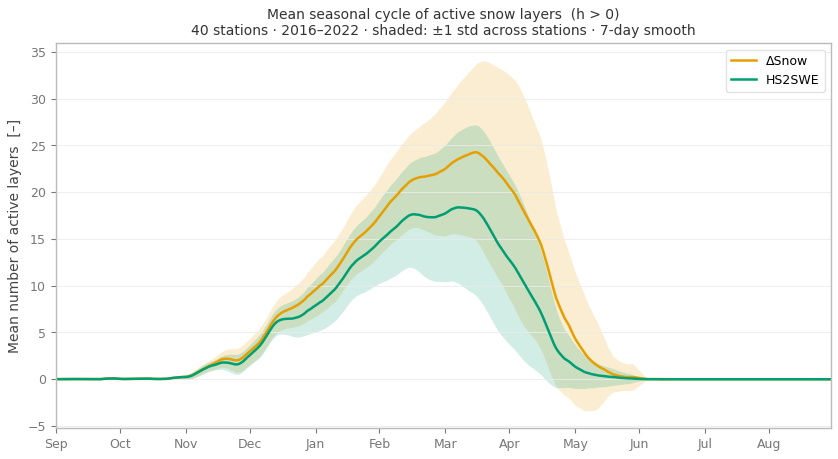

In [150]:
from plot_style import ALPHA

ds_sc = xr.open_dataset(out_nc)

EXCLUDE = {"Weisfluh_Joch"}
st_mask = np.array([s not in EXCLUDE for s in ds_sc["station"].values])

d_nl = ds_sc["dsnow_n_layers"].values[:, st_mask].astype(float)
h_nl = ds_sc["hs2swe_n_layers"].values[:, st_mask].astype(float)
times_sc = pd.DatetimeIndex(ds_sc["time"].values)
ds_sc.close()

cal_doy  = times_sc.dayofyear.values
sep1_doy = np.array([pd.Timestamp(y, 9, 1).dayofyear for y in times_sc.year])
hydro_doy = ((cal_doy - sep1_doy) % 365) + 1

doys = np.arange(1, 366)
d_doy_st = np.full((365, d_nl.shape[1]), np.nan)
h_doy_st = np.full((365, h_nl.shape[1]), np.nan)
for i, d in enumerate(doys):
    mask = hydro_doy == d
    if mask.sum():
        d_doy_st[i] = np.nanmean(d_nl[mask], axis=0)
        h_doy_st[i] = np.nanmean(h_nl[mask], axis=0)

d_mean = np.nanmean(d_doy_st, axis=1)
d_std  = np.nanstd(d_doy_st,  axis=1)
h_mean = np.nanmean(h_doy_st, axis=1)
h_std  = np.nanstd(h_doy_st,  axis=1)

def roll7(a):
    return pd.Series(a).rolling(7, center=True, min_periods=1).mean().values

d_mean_s, d_std_s = roll7(d_mean), roll7(d_std)
h_mean_s, h_std_s = roll7(h_mean), roll7(h_std)

fig, ax = plt.subplots(figsize=FIG.SINGLE)

ax.fill_between(doys, d_mean_s - d_std_s, d_mean_s + d_std_s,
                color=C.DSNOW,  alpha=ALPHA.BAND, lw=0)
ax.fill_between(doys, h_mean_s - h_std_s, h_mean_s + h_std_s,
                color=C.HS2SWE, alpha=ALPHA.BAND, lw=0)
ax.plot(doys, d_mean_s, color=C.DSNOW,  lw=1.8, label="ΔSnow")
ax.plot(doys, h_mean_s, color=C.HS2SWE, lw=1.8, label="HS2SWE")

month_pos    = [1, 31, 62, 92, 123, 153, 184, 214, 245, 275, 306, 336]
month_labels = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug"]
ax.set_xticks(month_pos)
ax.set_xticklabels(month_labels)
ax.set_xlim(1, 365)

ax.set_ylabel("Mean number of active layers  [–]")
ax.set_title(
    "Mean seasonal cycle of active snow layers  (h > 0)\n"
    "40 stations · 2016–2022 · shaded: ±1 std across stations · 7-day smooth",
    fontsize=10,
)
ax.legend()

fig.savefig(FIGURES_DIR / "seasonal_cycle_n_layers.png", **FIG.SAVE)
print(f"Saved: {FIGURES_DIR / 'seasonal_cycle_n_layers.png'}")
plt.show()